In [1]:
import pandas as pd

# dataframe1 客户表，存在重复key，用于测试一对多合并
df1 = pd.DataFrame({
    "customer_id": [1001, 1002, 1002, 1003, 1004, 1005],
    "name": ["张三", "李四", "李四", "王五", "赵六", "孙七"],
    "city": ["上海", "北京", "北京", "广州", "深圳", "杭州"],
    "joined_date": pd.to_datetime(["2023-01-15", "2023-03-02", "2023-03-02", "2023-05-20", "2024-02-11", "2024-06-30"])
})

# dataframe2 订单表，包含df1不存在的customer_id=1006，测试left/right/outer连接NaN效果
df2 = pd.DataFrame({
    "order_id": ["A001", "A002", "A003", "A004", "A005"],
    "customer_id": [1001, 1002, 1003, 1006, 1001],
    "user_id": [9001, 9002, 9003, 9006, 9001],
    "amount": [199.0, 358.5, 89.0, 1200.0, 45.5],
    "order_date": pd.to_datetime(["2023-06-10", "2023-07-22", "2023-09-01", "2024-01-15", "2024-03-05"])
})

pd.merge(df1, df2, on='customer_id', how='left')


,customer_id,name,city,joined_date,order_id,user_id,amount,order_date
0,1001,张三,上海,2023-01-15,A001,9001.0,199.0,2023-06-10
1,1001,张三,上海,2023-01-15,A005,9001.0,45.5,2024-03-05
2,1002,李四,北京,2023-03-02,A002,9002.0,358.5,2023-07-22
3,1002,李四,北京,2023-03-02,A002,9002.0,358.5,2023-07-22
4,1003,王五,广州,2023-05-20,A003,9003.0,89.0,2023-09-01
5,1004,赵六,深圳,2024-02-11,NaN,NaN,NaN,NaT
6,1005,孙七,杭州,2024-06-30,NaN,NaN,NaN,NaT


In [2]:
pd.crosstab(df1['city'], df1['name'])

name,孙七,张三,李四,王五,赵六
city,,,,,
上海,0,1,0,0,0
北京,0,0,2,0,0
广州,0,0,0,1,0
杭州,1,0,0,0,0
深圳,0,0,0,0,1


In [10]:
df2.sort_values(by='amount', ascending=False).reset_index(drop=True).groupby('customer_id').cumcount()+1

0    1
1    1
2    1
3    1
4    2
dtype: int64

In [15]:
# 用 load_breast_cancer（sklearn 自带）训练 LR
# 输出 confusion_matrix + classification_report

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import warnings

warnings.filterwarnings('ignore')  # 忽略警告

In [45]:

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()

# 交叉检验
scores = cross_val_score(model, X_train, y_train, cv=5)
print("交叉检验得分：", scores.mean())

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

交叉检验得分： 0.9396518987341773


Text(0.5, 0, 'False Positive Rate')

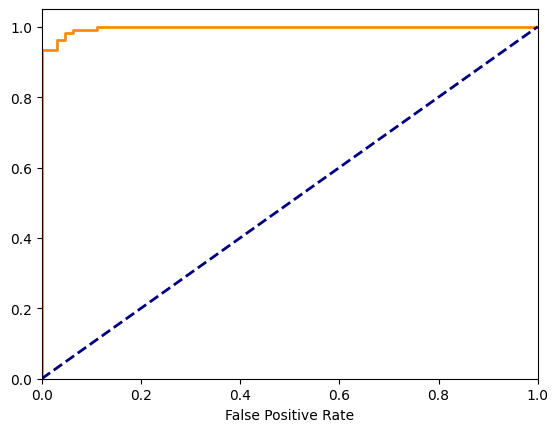

In [46]:
# 绘制ROC曲线
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')

array([2, 3, 4, 5, 7])

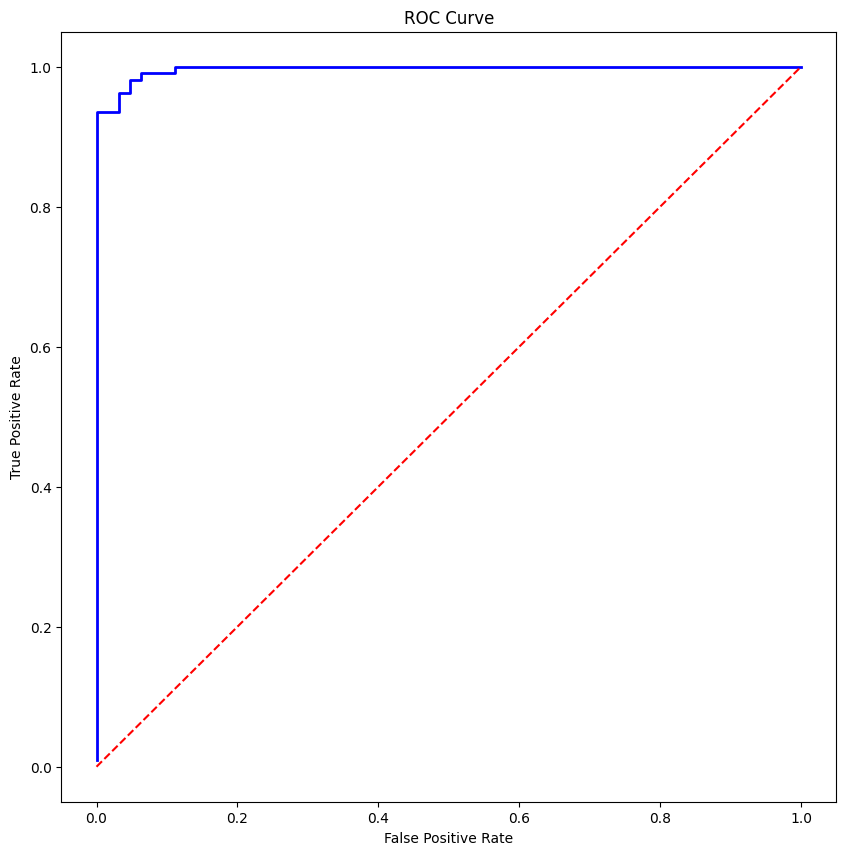

([np.float64(1.0),
  np.float64(0.9841269841269841),
  np.float64(0.9682539682539683),
  np.float64(0.9523809523809523),
  np.float64(0.9365079365079365),
  np.float64(0.9206349206349206),
  np.float64(0.9047619047619048),
  np.float64(0.8888888888888888),
  np.float64(0.873015873015873),
  np.float64(0.8571428571428571),
  np.float64(0.8412698412698413),
  np.float64(0.8253968253968254),
  np.float64(0.8095238095238095),
  np.float64(0.7936507936507936),
  np.float64(0.7777777777777778),
  np.float64(0.7619047619047619),
  np.float64(0.746031746031746),
  np.float64(0.7301587301587301),
  np.float64(0.7142857142857143),
  np.float64(0.6984126984126984),
  np.float64(0.6825396825396826),
  np.float64(0.6666666666666666),
  np.float64(0.6507936507936508),
  np.float64(0.6349206349206349),
  np.float64(0.6190476190476191),
  np.float64(0.6031746031746031),
  np.float64(0.5873015873015873),
  np.float64(0.5714285714285714),
  np.float64(0.5555555555555556),
  np.float64(0.5396825396825397

In [60]:
# 手写ROC排序
# y_test y_pred y_pred_proba

def return_y_pred(y_pred_proba, threshold):
    y_pred = []
    for i in range(len(y_pred_proba)):
        if y_pred_proba[i] >= threshold:
            y_pred.append(1)
        else:
            y_pred.append(0)
    return y_pred

# TPR
def calculate_tpr(y_test, y_pred_proba, threshold):
    total_T_num = np.bincount(y_test)[1]
    y_pred = return_y_pred(y_pred_proba, threshold)

    TP_num = 0
    for i in range(len(y_pred_proba)):
        if y_pred_proba[i] >= threshold and y_test[i] == 1:
            TP_num += 1
    return TP_num / total_T_num

# FPR
def calculate_fpr(y_test, y_pred_proba, threshold):
    total_F_num = np.bincount(y_test)[0]
    y_pred = return_y_pred(y_pred_proba, threshold)

    FP_num = 0
    for i in range(len(y_pred_proba)):
        if y_pred_proba[i] >= threshold and y_test[i] == 0:
            FP_num += 1
    return FP_num / total_F_num


def roc_c(y_test, y_pred_proba):
    X = []
    Y = []
    for threshold in np.sort(y_pred_proba):
        tpr = calculate_tpr(y_test, y_pred_proba, threshold)
        fpr = calculate_fpr(y_test, y_pred_proba, threshold)
        X.append(fpr)
        Y.append(tpr)
    return X, Y

def draw_roc(X, Y):
    plt.figure(figsize=(10, 10))
    plt.plot(X, Y, color='blue', linewidth=2)
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.show()

X, Y = roc_c(y_test, y_pred_proba)
draw_roc(X, Y)
X, Y